In [5]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import glob
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import joblib

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 경로 설정
base_path = 'C:/Users/User/Desktop/plant'

In [7]:
def extract_color_features(base_path):
    """
    이미지에서 색상 기반 특징을 추출하는 함수
    """
    features = []
    labels = []
    file_paths = []
    
    categories = ['apple', 'spear']
    
    for category in categories:
        folder_path = os.path.join(base_path, category)
        
        if os.path.exists(folder_path):
            # jpg 파일 찾기
            image_files = glob.glob(os.path.join(folder_path, '*.jpg'))
            print(f"\n{category} 폴더에서 {len(image_files)}개의 이미지를 찾았습니다.")
            
            for img_path in image_files:
                try:
                    # 이미지 로드
                    img = Image.open(img_path)
                    
                    # RGB로 변환 (이미지가 RGBA나 흑백일 경우를 대비)
                    if img.mode != 'RGB':
                        img = img.convert('RGB')
                    
                    img_array = np.array(img)
                    
                    # 색상 특징 추출
                    feature_vector = []
                    
                    # RGB 채널별 통계
                    for channel in range(3):  # R, G, B
                        channel_data = img_array[:, :, channel]
                        feature_vector.extend([
                            channel_data.mean(),      # 평균
                            channel_data.std(),       # 표준편차
                            channel_data.min(),       # 최소값
                            channel_data.max(),       # 최대값
                            np.median(channel_data),  # 중앙값
                        ])
                    
                    # HSV 색공간으로 변환하여 추가 특징 추출
                    hsv_img = img.convert('HSV')
                    hsv_array = np.array(hsv_img)
                    
                    # Hue(색조) 히스토그램 - 12개 구간
                    hue_hist, _ = np.histogram(hsv_array[:, :, 0], bins=12, range=(0, 255))
                    feature_vector.extend(hue_hist.tolist())
                    
                    features.append(feature_vector)
                    labels.append(category)
                    file_paths.append(img_path)
                    
                except Exception as e:
                    print(f"특징 추출 오류 {img_path}: {e}")
        else:
            print(f"경로를 찾을 수 없습니다: {folder_path}")
    
    return np.array(features), np.array(labels), file_paths

In [9]:
# 데이터 로드
print("=== Plant 이미지 데이터 로지스틱 회귀분석 ===")
print(f"데이터 경로: {base_path}")

# 색상 기반 특징 추출
print("\n색상 기반 특징을 추출합니다...")
X, y, file_paths = extract_color_features(base_path)

if len(X) == 0:
    print("이미지를 찾을 수 없습니다. 경로를 확인해주세요.")
else:
    print(f"\n총 이미지 수: {len(X)}")
    print(f"특징 벡터 크기: {X.shape[1]}")
    print(f"클래스 분포:")
    unique, counts = np.unique(y, return_counts=True)
    for cls, cnt in zip(unique, counts):
        print(f"  {cls}: {cnt}개")
    
    # 데이터 분할 (80% 학습, 20% 테스트)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\n학습 데이터: {len(X_train)}개")
    print(f"테스트 데이터: {len(X_test)}개")
    
    # 데이터 정규화
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

=== Plant 이미지 데이터 로지스틱 회귀분석 ===
데이터 경로: C:/Users/User/Desktop/plant

색상 기반 특징을 추출합니다...

apple 폴더에서 100개의 이미지를 찾았습니다.

spear 폴더에서 100개의 이미지를 찾았습니다.

총 이미지 수: 200
특징 벡터 크기: 27
클래스 분포:
  apple: 100개
  spear: 100개

학습 데이터: 160개
테스트 데이터: 40개


In [10]:
# 로지스틱 회귀 모델 생성 및 학습
print("\n로지스틱 회귀 모델 학습 중...")

model = LogisticRegression(
    random_state=42,          # 재현 가능한 결과를 위한 시드
    max_iter=1000,           # 최대 반복 횟수
    C=1.0,                   # 정규화 강도 (값이 작을수록 정규화 강함)
    solver='liblinear'       # 작은 데이터셋에 적합한 solver
)

# 모델 학습
model.fit(X_train_scaled, y_train)

# 예측
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# 예측 확률 (각 클래스에 속할 확률)
y_pred_proba = model.predict_proba(X_test_scaled)

print("모델 학습 완료!")


로지스틱 회귀 모델 학습 중...
모델 학습 완료!


In [11]:
# 성능 평가
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"\n=== 모델 성능 ===")
print(f"학습 정확도: {train_accuracy:.4f}")
print(f"테스트 정확도: {test_accuracy:.4f}")

# 분류 보고서
print("\n=== 분류 보고서 ===")
print(classification_report(y_test, y_pred_test))

# 혼동 행렬
cm = confusion_matrix(y_test, y_pred_test)
print("\n=== 혼동 행렬 ===")
print(cm)

# 잘못 분류된 이미지 분석
print("\n=== 잘못 분류된 이미지 ===")
misclassified_idx = np.where(y_test != y_pred_test)[0]
print(f"잘못 분류된 이미지 수: {len(misclassified_idx)}")

if len(misclassified_idx) > 0:
    print("\n잘못 분류된 샘플의 예측 확률 (처음 5개):")
    for i, idx in enumerate(misclassified_idx[:5]):
        true_label = y_test[idx]
        pred_label = y_pred_test[idx]
        prob = y_pred_proba[idx]
        print(f"{i+1}. 실제: {true_label}, 예측: {pred_label}, "
              f"확률: [apple: {prob[0]:.3f}, spear: {prob[1]:.3f}]")


=== 모델 성능 ===
학습 정확도: 0.9750
테스트 정확도: 0.9250

=== 분류 보고서 ===
              precision    recall  f1-score   support

       apple       0.95      0.90      0.92        20
       spear       0.90      0.95      0.93        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40


=== 혼동 행렬 ===
[[18  2]
 [ 1 19]]

=== 잘못 분류된 이미지 ===
잘못 분류된 이미지 수: 3

잘못 분류된 샘플의 예측 확률 (처음 5개):
1. 실제: apple, 예측: spear, 확률: [apple: 0.470, spear: 0.530]
2. 실제: spear, 예측: apple, 확률: [apple: 0.653, spear: 0.347]
3. 실제: apple, 예측: spear, 확률: [apple: 0.481, spear: 0.519]


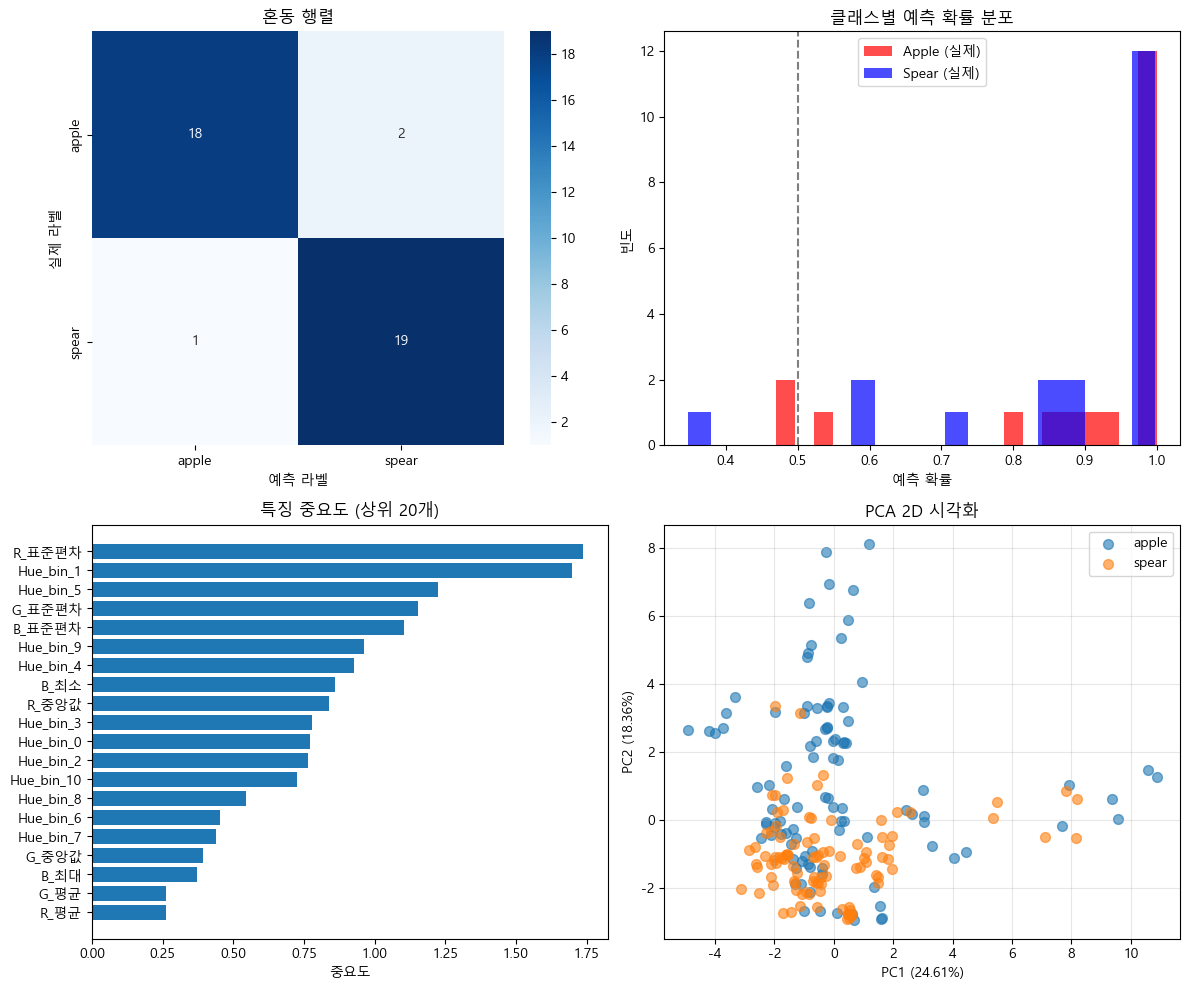

In [12]:
# 시각화를 위한 그림 생성
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. 혼동 행렬 히트맵
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['apple', 'spear'],
            yticklabels=['apple', 'spear'],
            ax=axes[0, 0])
axes[0, 0].set_title('혼동 행렬')
axes[0, 0].set_ylabel('실제 라벨')
axes[0, 0].set_xlabel('예측 라벨')

# 2. 예측 확률 분포
# apple로 예측된 경우의 apple 확률
apple_probs = y_pred_proba[y_test == 'apple'][:, 0]
# spear로 예측된 경우의 spear 확률
spear_probs = y_pred_proba[y_test == 'spear'][:, 1]

axes[0, 1].hist(apple_probs, bins=20, alpha=0.7, label='Apple (실제)', color='red')
axes[0, 1].hist(spear_probs, bins=20, alpha=0.7, label='Spear (실제)', color='blue')
axes[0, 1].set_title('클래스별 예측 확률 분포')
axes[0, 1].set_xlabel('예측 확률')
axes[0, 1].set_ylabel('빈도')
axes[0, 1].legend()
axes[0, 1].axvline(x=0.5, color='black', linestyle='--', alpha=0.5)

# 3. 특징 중요도 (상위 20개)
feature_importance = np.abs(model.coef_[0])
top_features_idx = np.argsort(feature_importance)[-20:]
top_features = feature_importance[top_features_idx]

# 특징 이름 생성
feature_names = []
for i in top_features_idx:
    if i < 15:  # RGB 통계 특징
        channel = i // 5
        stat = i % 5
        channels = ['R', 'G', 'B']
        stats = ['평균', '표준편차', '최소', '최대', '중앙값']
        feature_names.append(f'{channels[channel]}_{stats[stat]}')
    else:  # Hue 히스토그램
        feature_names.append(f'Hue_bin_{i-15}')

axes[1, 0].barh(range(len(top_features)), top_features)
axes[1, 0].set_yticks(range(len(top_features)))
axes[1, 0].set_yticklabels(feature_names)
axes[1, 0].set_title('특징 중요도 (상위 20개)')
axes[1, 0].set_xlabel('중요도')

# 4. PCA 2D 시각화
pca = PCA(n_components=2)
X_all_scaled = scaler.fit_transform(X)  # 전체 데이터 스케일링
X_pca = pca.fit_transform(X_all_scaled)

for label in np.unique(y):
    mask = y == label
    axes[1, 1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                      label=label, alpha=0.6, s=50)

axes[1, 1].set_title('PCA 2D 시각화')
axes[1, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[1, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:

# 학습된 모델과 전처리 도구 저장
joblib.dump(model, 'plant_logistic_model.pkl')
joblib.dump(scaler, 'plant_scaler.pkl')

print("\n모델이 저장되었습니다:")
print("- plant_logistic_model.pkl: 학습된 로지스틱 회귀 모델")
print("- plant_scaler.pkl: 데이터 정규화 도구")


모델이 저장되었습니다:
- plant_logistic_model.pkl: 학습된 로지스틱 회귀 모델
- plant_scaler.pkl: 데이터 정규화 도구
